LOGISTICS DELIVERY PERFORMANCE ANALYSIS

Proyek ini menganalisis data pengiriman logistik untuk mengetahui performa pengiriman dan mengidentifikasi masalah keterlambatan

DATA LOADING & DATA UNDERSTANDING

Membaca dan memahami data
Berisi 1005 baris dan 10 kolom

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


df = pd.read_csv('/content/logistics_delivery.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1005 non-null   object 
 1   order_date        1005 non-null   object 
 2   courier           1005 non-null   object 
 3   origin_city       1005 non-null   object 
 4   destination_city  1005 non-null   object 
 5   weight_kg         1002 non-null   float64
 6   shipping_cost     1002 non-null   float64
 7   delivery_days     1005 non-null   int64  
 8   status            1005 non-null   object 
 9   customer_type     999 non-null    object 
dtypes: float64(2), int64(1), object(7)
memory usage: 78.6+ KB


DATA CLEANING

*   Date
*   Duplicates
*   Missing Values

In [30]:
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.drop_duplicates()
df['weight_kg'] = df['weight_kg'].fillna(df['weight_kg'].median())
df['shipping_cost'] = df['shipping_cost'].fillna(df['shipping_cost'].median())
df['customer_type'] = df['customer_type'].fillna('Unknown')

EXPLORATORY DATA ANALYSIS (EDA)

Overall Performance

Persentase terkirim 84% dengan keterlambatan 12.4% dan 3.6% batal

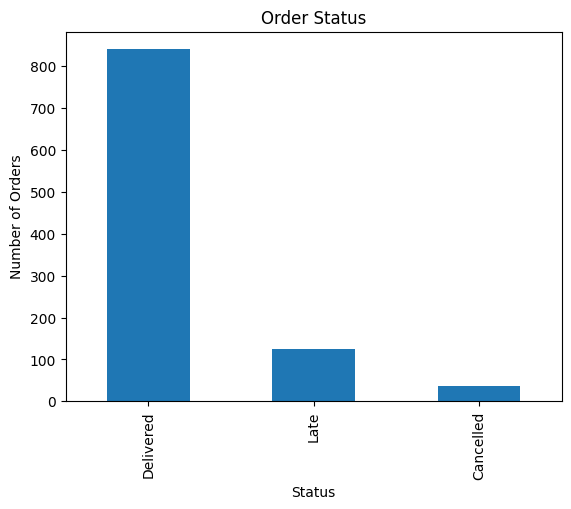

In [32]:
df['status'].value_counts().plot(kind='bar')

plt.title('Order Status')
plt.xlabel('Status')
plt.ylabel('Number of Orders')

plt.show()

In [33]:
status_percentage = (
    df['status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_percentage

,proportion
status,
Delivered,84.0
Late,12.4
Cancelled,3.6


Delivery Performance

Rata-rata pengiriman semua kurir sekitar 3,3 - 4 hari

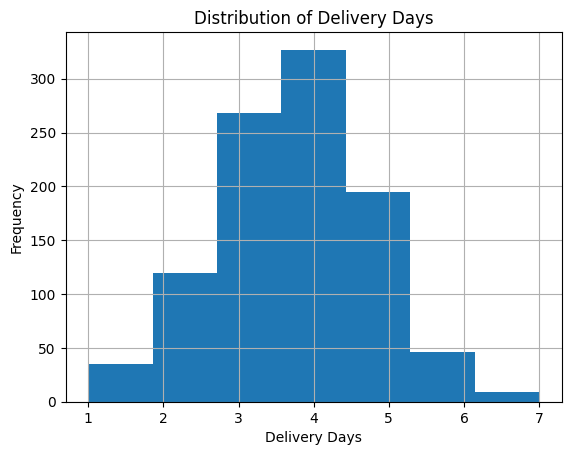

In [35]:
df['delivery_days'].hist(bins=7)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Frequency')

plt.show()

In [36]:
df.groupby('courier')['delivery_days'].agg(
    ['count','mean','median']
)

,count,mean,median
courier,,,
AnterAja,206,4.072816,4.0
J&T,268,3.936567,4.0
JNE,293,3.511945,4.0
SiCepat,233,3.339056,3.0


Courier Analysis

Persentase keterlambatan bervariasi diantara semua kurir dari 7.8% - 15%

In [56]:
df['is_late'] = (df['status'] == 'Late').astype(int)

late_rate = (df.groupby('courier')['is_late'].mean().mul(100).round(2))

late_rate

,is_late
courier,
AnterAja,15.05
J&T,14.18
JNE,7.85
SiCepat,13.73


In [57]:
courier_summary = df.groupby('courier').agg(
    total_orders = ('order_id','count'),
    late_orders = ('is_late','sum'),
    avg_delivery_days = ('delivery_days','mean'),
    median_delivery_days = ('delivery_days','median'),
    late_rate = ('is_late','mean')
)

courier_summary['late_rate'] = courier_summary['late_rate'].mul(100).round(2)

courier_summary

,total_orders,late_orders,avg_delivery_days,median_delivery_days,late_rate
courier,,,,,
AnterAja,206,31,4.072816,4.0,15.05
J&T,268,38,3.936567,4.0,14.18
JNE,293,23,3.511945,4.0,7.85
SiCepat,233,32,3.339056,3.0,13.73


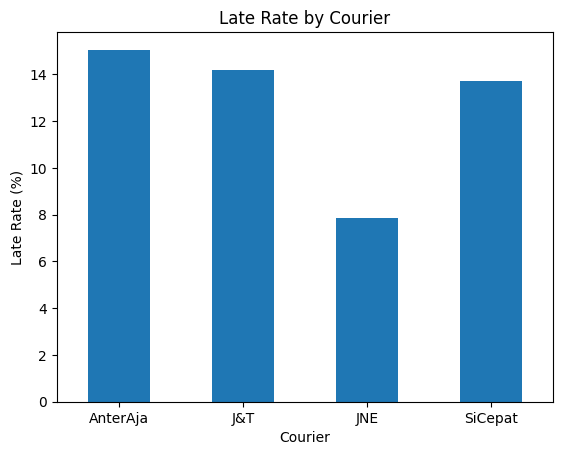

In [40]:
courier_summary['late_rate'].plot(kind='bar')

plt.title('Late Rate by Courier')
plt.xlabel('Courier')
plt.ylabel('Late Rate (%)')
plt.xticks(rotation=0)

plt.show()

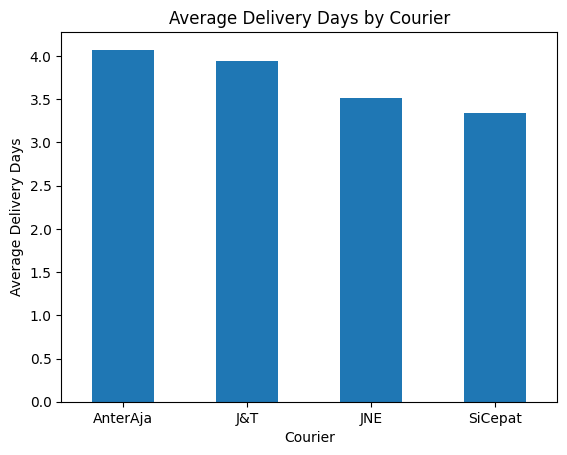

In [41]:
courier_summary['avg_delivery_days'].plot(kind='bar')

plt.title('Average Delivery Days by Courier')
plt.xlabel('Courier')
plt.ylabel('Average Delivery Days')
plt.xticks(rotation=0)

plt.show()

Weight Analysis

Paket dengan berat 5-10kg memiliki persentase keterlambatan lebih tinggi dibanding paket dengan berat dibawahnya

In [58]:
df['weight_category'] = pd.cut(
    df['weight_kg'],
    bins = [0,1,3,5,10],
    labels = ['0-1kg','1-3kg','3-5kg','5-10kg']
)

weight_summary = df.groupby(
    'weight_category',
    observed=True
).agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
)

weight_summary['late_rate'] = (
    weight_summary['late_rate']
    .mul(100)
    .round(2)
)

weight_summary

,total_orders,late_orders,late_rate
weight_category,,,
0-1kg,168,20,11.90
1-3kg,505,57,11.29
3-5kg,228,27,11.84
5-10kg,99,20,20.20


In [59]:
courier_weight = df.groupby(
    ['courier', 'weight_category'],
    observed=True
).agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    late_rate=('is_late', 'mean')
)

courier_weight['late_rate'] = (
    courier_weight['late_rate']
    .mul(100)
    .round(2)
)

courier_weight

total_orders  late_orders  late_rate
courier  weight_category                                      
AnterAja 0-1kg                      36            7      19.44
         1-3kg                      99           14      14.14
         3-5kg                      54            5       9.26
         5-10kg                     17            5      29.41
J&T      0-1kg                      55           10      18.18
         1-3kg                     132           15      11.36
         3-5kg                      58            9      15.52
         5-10kg                     23            4      17.39
JNE      0-1kg                      44            2       4.55
         1-3kg                     152           11       7.24
         3-5kg                      64            4       6.25
         5-10kg                     33            6      18.18
SiCepat  0-1kg                      33            1       3.03
         1-3kg                     122           17      13.93
         3-5kg                      52            9      17.31
         5-10kg                     26            5      19.23

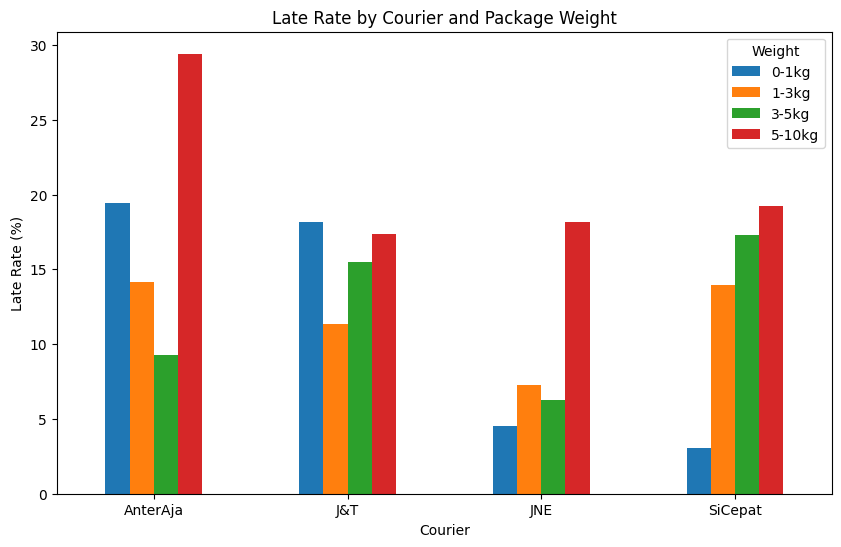

In [45]:
courier_weight_plot = courier_weight['late_rate'].unstack()

courier_weight_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Late Rate by Courier and Package Weight')
plt.xlabel('Courier')
plt.ylabel('Late Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Weight')

plt.show()

Correlation Analysis

Korelasi antara berat, harga, dan waktu pengiriman. Ditemukan korelasi positif yang kuat antara berat dengan harga, sedangkan harga dan berat dengan waktu pengiriman ditemukan korelasi positif yang rendah

In [49]:
df[['weight_kg', 'shipping_cost', 'delivery_days']].corr()

,weight_kg,shipping_cost,delivery_days
weight_kg,1.000000,0.872762,0.142566
shipping_cost,0.872762,1.000000,0.240148
delivery_days,0.142566,0.240148,1.000000


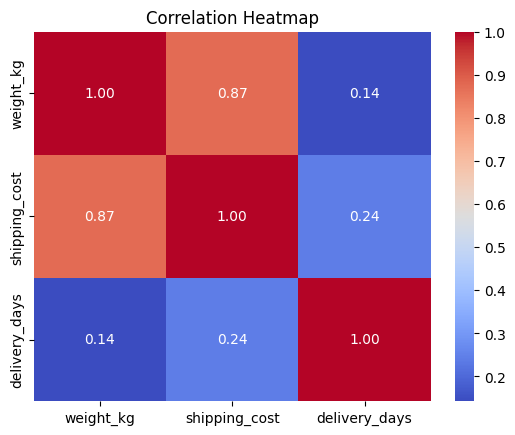

In [50]:
corr = df[
    ['weight_kg', 'shipping_cost', 'delivery_days']
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

Route Analysis

Beberapa rute pengiriman memiliki persentase keterlambatan yang tinggi

In [51]:
df['route'] = (
    df['origin_city'] + ' → ' + df['destination_city']
)

route_summary = df.groupby('route').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean')
)

route_summary['late_rate'] = (
    route_summary['late_rate']
    .mul(100)
    .round(2)
)

route_summary.sort_values(
    'late_rate',
    ascending=False
).head(10)

,total_orders,late_orders,avg_delivery_days,late_rate
route,,,,
Jakarta → Tangerang,12,6,4.333333,50.00
Semarang → Tangerang,9,4,3.888889,44.44
Surabaya → Bandung,17,7,4.058824,41.18
Tangerang → Yogyakarta,19,6,3.842105,31.58
Bekasi → Tangerang,16,5,4.000000,31.25
Semarang → Depok,16,4,4.125000,25.00
Depok → Yogyakarta,17,4,3.764706,23.53
Bekasi → Yogyakarta,13,3,4.000000,23.08
Jakarta → Depok,13,3,4.230769,23.08


Customer Analysis

Hubungan antara customer dengan waktu pengiriman dan keterlambatan

In [54]:
customer_summary = df.groupby('customer_type').agg(
    total_orders=('order_id', 'count'),
    late_orders=('is_late', 'sum'),
    avg_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean')
)

customer_summary['late_rate'] = (
    customer_summary['late_rate']
    .mul(100)
    .round(2)
)

customer_summary

,total_orders,late_orders,avg_delivery_days,late_rate
customer_type,,,,
New,370,50,3.702703,13.51
Returning,624,74,3.703526,11.86
Unknown,6,0,3.333333,0.00


BUSINESS RECOMMENDATIONS

1. Monitoring performa kurir dengan indikator seperti waktu pengiriman, keterlambatan, dan volume paket
2. Investigasi proses pengiriman paket yang lebih berat, karena memiliki persentase keterlambatan yang lebih tinggi
3. Investigasi rute dengan persentase keterlambatan yang tinggi